In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/rickytarus/fe-gwp1-dataset-prob5/FE-GWP1_dataset_Prob5.csv


In [12]:
df = pd.read_csv(
    '/kaggle/input/datasets/rickytarus/fe-gwp1-dataset-prob5/FE-GWP1_dataset_Prob5.csv'
)

# Split the single column into four columns
df = df.iloc[:, 0].str.split(',', expand=True)

# Assign column names
df.columns = ['Period', 'X', 'Y', 'Z']

# Convert all columns to numeric
df = df.apply(pd.to_numeric)

print(df.head())
print(df.columns.tolist())

   Period         X         Y         Z
0       1  0.082217  0.577180 -0.312377
1       2  0.078359 -0.317703 -0.555119
2       3  1.379785  0.837258 -0.991766
3       4  2.834353  1.689486 -1.889942
4       5  2.284564  1.124723 -2.199465
['Period', 'X', 'Y', 'Z']


**Visual Inspection**

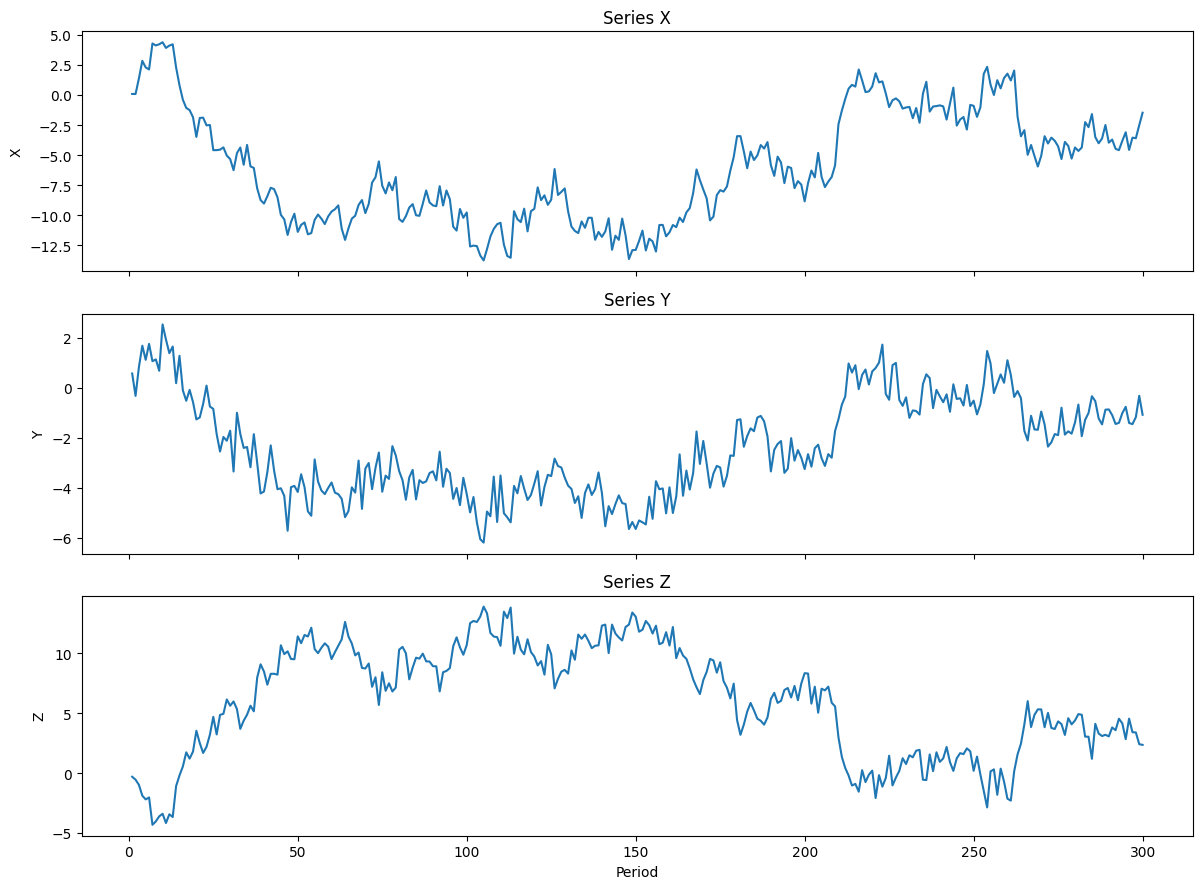

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(df['Period'], df['X'])
axes[0].set_title('Series X')
axes[0].set_ylabel('X')

axes[1].plot(df['Period'], df['Y'])
axes[1].set_title('Series Y')
axes[1].set_ylabel('Y')

axes[2].plot(df['Period'], df['Z'])
axes[2].set_title('Series Z')
axes[2].set_ylabel('Z')
axes[2].set_xlabel('Period')

plt.tight_layout()
plt.show()

The plots indicate that X, Y, and Z are NOT randomly varying about any mean, but rather trending. This means that the series might not be stationary. The obvious problem is that the variables seem to move together over time and, therefore, formal unit root and cointegration tests are needed.

**Augmented Dickey-Fuller (ADF) Tests**

In [13]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')

    print("="*60)
    print(f"Augmented Dickey-Fuller Test: {name}")
    print("="*60)

    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"No. Observations: {result[3]}")

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.6f}")

    if result[1] < 0.05:
        print("\nDecision: Reject the null hypothesis.")
        print(f"{name} is stationary.")
    else:
        print("\nDecision: Fail to reject the null hypothesis.")
        print(f"{name} has a unit root (non-stationary).")
adf_test(df['X'], 'X')
adf_test(df['Y'], 'Y')
adf_test(df['Z'], 'Z')

Augmented Dickey-Fuller Test: X
ADF Statistic : -2.486236
p-value       : 0.118859
Lags Used     : 6
No. Observations: 293

Critical Values:
   1%: -3.452867
   5%: -2.871455
   10%: -2.572053

Decision: Fail to reject the null hypothesis.
X has a unit root (non-stationary).
Augmented Dickey-Fuller Test: Y
ADF Statistic : -2.080296
p-value       : 0.252511
Lags Used     : 4
No. Observations: 295

Critical Values:
   1%: -3.452713
   5%: -2.871388
   10%: -2.572017

Decision: Fail to reject the null hypothesis.
Y has a unit root (non-stationary).
Augmented Dickey-Fuller Test: Z
ADF Statistic : -1.966677
p-value       : 0.301372
Lags Used     : 1
No. Observations: 298

Critical Values:
   1%: -3.452486
   5%: -2.871288
   10%: -2.571964

Decision: Fail to reject the null hypothesis.
Z has a unit root (non-stationary).


In [21]:
# Creating differences for non-stationary levels
df['dX'] = df['X'].diff()
df['dY'] = df['Y'].diff()
df['dZ'] = df['Z'].diff()
adf_test(df['dX'].dropna(), 'ΔX')
adf_test(df['dY'].dropna(), 'ΔY')
adf_test(df['dZ'].dropna(), 'ΔZ')

Augmented Dickey-Fuller Test: ΔX
ADF Statistic : -10.339658
p-value       : 0.000000
Lags Used     : 3
No. Observations: 295

Critical Values:
   1%: -3.452713
   5%: -2.871388
   10%: -2.572017

Decision: Reject the null hypothesis.
ΔX is stationary.
Augmented Dickey-Fuller Test: ΔY
ADF Statistic : -12.012434
p-value       : 0.000000
Lags Used     : 3
No. Observations: 295

Critical Values:
   1%: -3.452713
   5%: -2.871388
   10%: -2.572017

Decision: Reject the null hypothesis.
ΔY is stationary.
Augmented Dickey-Fuller Test: ΔZ
ADF Statistic : -22.510537
p-value       : 0.000000
Lags Used     : 0
No. Observations: 298

Critical Values:
   1%: -3.452486
   5%: -2.871288
   10%: -2.571964

Decision: Reject the null hypothesis.
ΔZ is stationary.


**Johansen Cointegration Test**

In [25]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
data = df[['X', 'Y', 'Z']]
johansen_test = coint_johansen(
    data,
    det_order=0,
    k_ar_diff=1
)
trace_df = pd.DataFrame({
    'Hypothesis': ['r = 0', 'r ≤ 1', 'r ≤ 2'],
    'Trace Statistic': johansen_test.lr1,
    '90% CV': johansen_test.cvt[:,0],
    '95% CV': johansen_test.cvt[:,1],
    '99% CV': johansen_test.cvt[:,2]
})

print(trace_df)

  Hypothesis  Trace Statistic   90% CV   95% CV   99% CV
0      r = 0       262.065729  27.0669  29.7961  35.4628
1      r ≤ 1       128.769652  13.4294  15.4943  19.9349
2      r ≤ 2         3.925153   2.7055   3.8415   6.6349


**r = 0**: Reject the null hypothesis of no cointegration because the value of the test statistic (262.07) is greater than the critical value (29.80).

**r ≤ 1**: Null hypothesis of at most one cointegrating relationship rejected, with a value of 128.77 > 15.49.

**r ≤ 2**: The null hypothesis of at most two cointegrating relationships is rejected at the 5% significance level.


So, the Trace test shows a cointegration rank of 3, meaning that all three linear combinations are stationary.

In [26]:
# Maximum EigenValue Test
maxeig_df = pd.DataFrame({
    'Hypothesis': ['r = 0', 'r = 1', 'r = 2'],
    'Max-Eigen Statistic': johansen_test.lr2,
    '90% CV': johansen_test.cvm[:,0],
    '95% CV': johansen_test.cvm[:,1],
    '99% CV': johansen_test.cvm[:,2]
})

print(maxeig_df)

  Hypothesis  Max-Eigen Statistic   90% CV   95% CV   99% CV
0      r = 0           133.296077  18.8928  21.1314  25.8650
1      r = 1           124.844499  12.2971  14.2639  18.5200
2      r = 2             3.925153   2.7055   3.8415   6.6349


**r = 0**: Reject the null hypothesis.

**r = 1**: Reject the null hypothesis.

**r = 2**: Reject the null hypothesis.


The Maximum Eigenvalue test also suggests a cointegration rank of 3.